## Inusrance Fraud Detection

## Importing Necessary Libraries

In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import joblib
import os

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)


In [250]:
# Load raw data
df = pd.read_csv(r'C:\NG\insurance_fraud_detection\data\raw\insurance_claim_fraud_detection_dataset(in).csv')

**Data preprocessing and Cleaning**

## Creating a Working Copy of Raw Data

In [251]:
df_clean = df.copy()

In [252]:
df_clean.head()

,claim_id,customer_age,gender,occupation,location_type,customer_tenure_years,policy_type,policy_duration_years,premium_amount,annual_premium,coverage_amount,policy_value,deductible_amount,policy_changes_last_year,claim_amount,repair_estimate,claim_type,incident_severity,incident_location,previous_claims_count,claims_last_12_months,total_claim_amount_previous,claim_frequency_score,police_report_available,witness_available,third_party_involved,incident_hour,weekend_incident,documentation_score,suspicious_activity_score,claim_amount_to_coverage_ratio,premium_to_claim_ratio,policy_start_date,policy_end_date,incident_date,claim_filed_date,claim_settlement_date,claim_submission_delay_days,fraud_investigation_result,claim_rejected,legal_case_filed,settlement_approved,fraud
0,CLM000001,49,Female,Self-employed,Semi-Urban,7.4,Property,3.3,"$22,420",21067,"$486,870",479675,"$11,790",4,"$20,218","$41,020",Medical,Major,Public Place,0.0,1,0,1.83,Yes,Yes,Yes,11,Yes,10.00,4.90,4.15%,110.89%,8/3/2020,2/4/2024,24-May-23,31/05/2023,7/22/2023,7.0,Clear,No,No,Yes,0
1,CLM000002,29,Female,Business,Urban,5.5,auto,3.8,"$15,431",17382,"$721,974",739819,"$12,548",1,"$222,106","$241,421",Medical,Major,Road,1.0,0,62030,2.31,Yes,Yes,No,2,Yes,7.66,5.74,30.76%,6.95%,9/1/2022,1/25/2025,8/13/2024,19-Aug-24,12/19/2024,6.0,Clear,No,No,Yes,0
2,CLM000003,35,male,Salaried,Semi-Urban,1.5,AUTO,7.7,"$18,243",18357,"$892,064",917373,"$24,292",0,"$5,000","$8,655",Accident,Minor,Road,1.0,2,7985,5.20,No,No,No,19,Yes,7.43,2.01,0.56%,364.86%,29-Mar-23,29-11-2024,4-Sep-22,23-Sep-22,10/25/2022,19.0,Clear,No,No,Yes,0
3,CLM000004,24,Female,Business,Urban,7.2,Auto,5.7,"$18,491",18006,"$50,000",156216,"$1,000",3,"$212,674","$239,787",Medical,Minor,Hospital,2.0,1,227104,5.62,no,Yes,No,22,Yes,9.77,5.40,425.35%,8.69%,18/07/2018,8/20/2019,31-12-2022,3/11/2023,5/24/2023,70.0,Clear,No,No,Yes,0
4,CLM000005,41,Male,Salaried,Urban,5.4,Travel,5.3,"$17,354",16708,"$50,000",50271,"$2,717",0,"$73,521","$103,984",Theft,Moderate,Hospital,1.0,0,63514,0.60,No,Yes,Yes,8,No,7.00,6.76,147.04%,23.60%,25-Aug-23,3/24/2027,5/9/2024,11/6/2024,13-12-2024,62.0,Clear,No,No,Yes,0


In [253]:
df.shape

(51000, 43)

### Dataset Overview

- We loaded **51,000 insurance claims** with **43 features** — a solid-sized dataset for fraud detection.
- Columns cover customer profile, policy details, claim amounts, incident info, and supporting evidence.
- The target column `fraud` (0 or 1) is what the model will learn to predict.
- With 43 features, some will be redundant or irrelevant — cleaning this up is our first priority.
- We always work on a copy of the raw data so the original file is preserved for reference.

## Dropping Data Leakage Columns

In [254]:
leakage_cols=['fraud_investigation_result','claim_rejected','legal_case_filed','settlement_approved','claim_settlement_date']
df_clean.drop(columns=leakage_cols, axis=1, inplace=True)

In [255]:
df_clean.shape

(51000, 38)

### Dropped These Columns

- Columns like `fraud_investigation_result` and `claim_rejected` directly reveal the fraud outcome.
- In real-world deployment, these results are not available *before* we detect fraud, so the model must never see them during training.
- when future information sneaks into training data and inflates accuracy artificially.
- `claim_settlement_date` was also removed since settlement happens *after* the fraud decision is made.
- After removing these 5 columns, we are left with 38 features that represent genuine pre-detection signals only.

## Checking for Duplicate Records

In [256]:
df_clean.duplicated().sum()

np.int64(1000)

In [257]:
df_clean =df_clean.drop_duplicates()

In [258]:
df_clean.duplicated().sum()

np.int64(0)

### Duplicate Records

- Found **1,000 duplicate rows** out of 51,000 — about 2% of the dataset.
- Keeping duplicates would make the model see the same claim twice, biasing it toward those patterns.
- After removal, we have **50,000 unique records** — clean and ready for the next step.


## Data Cleaning

### Cleaning Currency Columns

In [259]:


currency_cols = [
    'premium_amount',
    'coverage_amount', 
    'deductible_amount',
    'claim_amount',
    'repair_estimate'
]

print("BEFORE cleaning:")
print(df_clean[currency_cols].head())
print("\nData types:", df_clean[currency_cols].dtypes.tolist())

BEFORE cleaning:
  premium_amount coverage_amount deductible_amount claim_amount  \
0       $22,420        $486,870           $11,790      $20,218    
1       $15,431        $721,974           $12,548     $222,106    
2       $18,243        $892,064           $24,292       $5,000    
3       $18,491         $50,000            $1,000     $212,674    
4       $17,354         $50,000            $2,717      $73,521    

  repair_estimate  
0        $41,020   
1       $241,421   
2         $8,655   
3       $239,787   
4       $103,984   

Data types: [dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O')]


In [260]:
# Currency cleaning function
def clean_currency(value):
    
    if pd.isnull(value):
        return np.nan
    
    value = str(value)
    cleaned = re.sub(r'[\$,\s"\']', '', value)
    
    try:
        return float(cleaned)
    except ValueError:
        return np.nan  

# Apply to all currency columns
for col in currency_cols:
    df_clean[col] = df_clean[col].apply(clean_currency)

print("AFTER cleaning:")
print(df_clean[currency_cols].head())
print("\nData types:", df_clean[currency_cols].dtypes.tolist())

AFTER cleaning:
   premium_amount  coverage_amount  deductible_amount  claim_amount  \
0         22420.0         486870.0            11790.0       20218.0   
1         15431.0         721974.0            12548.0      222106.0   
2         18243.0         892064.0            24292.0        5000.0   
3         18491.0          50000.0             1000.0      212674.0   
4         17354.0          50000.0             2717.0       73521.0   

   repair_estimate  
0          41020.0  
1         241421.0  
2           8655.0  
3         239787.0  
4         103984.0  

Data types: [dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64')]


### Cleaned Currency Columns

- Currency values like `$22,420` were stored as plain text .
- We stripped the `$` sign and commas so `"$22,420"` becomes `22420.0` — a proper float number.
- All 5 currency columns are now `float64` type, ready for calculations and model training.
- Missing values were preserved as `NaN` so they can be handled properly in the imputation step.


### Cleaning Percentage Columns

In [261]:
pct_cols = ['claim_amount_to_coverage_ratio', 'premium_to_claim_ratio']

print("BEFORE:")
print(df_clean[pct_cols].head())
print("Data types:", df_clean[pct_cols].dtypes.tolist())

BEFORE:
  claim_amount_to_coverage_ratio premium_to_claim_ratio
0                          4.15%                110.89%
1                         30.76%                  6.95%
2                          0.56%                364.86%
3                        425.35%                  8.69%
4                        147.04%                 23.60%
Data types: [dtype('O'), dtype('O')]


In [262]:
def clean_percentage(value):
    
    if pd.isnull(value):
        return np.nan
    value = str(value).replace('%', '').strip()
    try:
        return float(value) / 100 
    except ValueError:
        return np.nan

for col in pct_cols:
    df_clean[col] = df_clean[col].apply(clean_percentage)

print("\nAFTER:")
print(df_clean[pct_cols].head(3))
print("Data types:", df_clean[pct_cols].dtypes.tolist())


AFTER:
   claim_amount_to_coverage_ratio  premium_to_claim_ratio
0                          0.0415                  1.1089
1                          0.3076                  0.0695
2                          0.0056                  3.6486
Data types: [dtype('float64'), dtype('float64')]


### We Removed the % Symbol

- The `%` symbol turned numeric ratios into text — `"30.76%"` and `30.76` are completely different.
- We stripped the `%` and divided by 100 to convert to decimal form — e.g., `"30.76%"` becomes `0.3076`.
- Dividing by 100 also normalizes the scale to 0-1 range, which works better with most ML algorithms.
- Two ratio columns were cleaned: `claim_amount_to_coverage_ratio` and `premium_to_claim_ratio`.


### Standardizing Categorical Columns

In [263]:
# Checking categorical columns for inconsistencies
categorical_cols = ['gender', 'occupation', 'location_type', 'policy_type', 
                    'claim_type', 'incident_severity', 'incident_location',
                    'police_report_available', 'witness_available', 
                    'third_party_involved', 'weekend_incident']

for col in categorical_cols:
    print(f"\n{col}: {df_clean[col].unique()[:10]}")  


gender: ['Female' 'male' 'Male' 'FEMALE' 'Other']

occupation: ['Self-employed' 'Business' 'Salaried' 'Retired' 'Student' 'salaried']

location_type: ['Semi-Urban' 'Urban' 'Rural']

policy_type: ['Property' 'auto' 'AUTO' 'Auto' 'Travel' 'Life' 'Health' 'Vehicle']

claim_type: ['Medical' 'Accident' 'Theft' 'Loss' 'Damage' 'Fire']

incident_severity: ['Major' 'Minor' 'Moderate' 'Severe' nan 'MAJOR' 'minor']

incident_location: ['Public Place' 'Road' 'Hospital' 'Home' 'Workplace' 'Other']

police_report_available: ['Yes' 'No' 'no' nan 'N' 'yes' 'Y']

witness_available: ['Yes' 'No' 'yes' 'Y' nan 'no' 'N']

third_party_involved: ['Yes' 'No']

weekend_incident: ['Yes' 'No']


In [264]:
def standardize_text(value):
    
    if pd.isnull(value):
        return np.nan
    return str(value).strip().title()

for col in categorical_cols:
    df_clean[col] = df_clean[col].apply(standardize_text)

yes_no_cols = ['police_report_available', 'witness_available', 
               'third_party_involved', 'weekend_incident']

yes_no_map = {
    'Yes': 'Yes', 'Y': 'Yes', 'yes': 'Yes', 'y': 'Yes', '1': 'Yes',
    'No': 'No', 'N': 'No', 'no': 'No', 'n': 'No', '0': 'No'
}

for col in yes_no_cols:
    df_clean[col] = df_clean[col].map(yes_no_map).fillna(df_clean[col])

gender_map = {
    'Male': 'Male', 'M': 'Male', 'male': 'Male',
    'Female': 'Female', 'F': 'Female', 'female': 'Female'
}
df_clean['gender'] = df_clean['gender'].apply(standardize_text).map(gender_map)

for col in categorical_cols:
    print(f"{col}: {df_clean[col].unique()}")

gender: ['Female' 'Male' nan]
occupation: ['Self-Employed' 'Business' 'Salaried' 'Retired' 'Student']
location_type: ['Semi-Urban' 'Urban' 'Rural']
policy_type: ['Property' 'Auto' 'Travel' 'Life' 'Health' 'Vehicle']
claim_type: ['Medical' 'Accident' 'Theft' 'Loss' 'Damage' 'Fire']
incident_severity: ['Major' 'Minor' 'Moderate' 'Severe' nan]
incident_location: ['Public Place' 'Road' 'Hospital' 'Home' 'Workplace' 'Other']
police_report_available: ['Yes' 'No' nan]
witness_available: ['Yes' 'No' nan]
third_party_involved: ['Yes' 'No']
weekend_incident: ['Yes' 'No']


### We Standardized Categorical Columns

- The same category had multiple spellings — `"male"`, `"Male"`, `"MALE"` were all treated as different values.
- We applied title-case formatting to unify all values: `"AUTO"` becomes `"Auto"`, `"salaried"` becomes `"Salaried"`.
- Yes/No columns had many variants like `"Y"`, `"y"`, `"yes"`, `"1"` — all mapped to a clean `"Yes"` or `"No"`.
- `"Other"` gender values became `NaN` after mapping — these will be filled in the missing values step.
- Inconsistent categories create extra dummy variables during encoding and confuse the model unnecessarily.

### Date Cleaning

In [265]:
date_cols = ['policy_start_date', 'policy_end_date', 'incident_date', 'claim_filed_date']

for col in date_cols:
    print(f"\n{col} samples:")
    print(df_clean[col].head(10).tolist())


policy_start_date samples:
['8/3/2020', '9/1/2022', '29-Mar-23', '18/07/2018', '25-Aug-23', '28-May-20', '6/27/2020', '3/27/2021', '12/6/2023', '5/19/2020']

policy_end_date samples:
['2/4/2024', '1/25/2025', '29-11-2024', '8/20/2019', '3/24/2027', '4/10/2025', '5-Jun-25', '6/7/2022', '4/16/2028', '8-Aug-23']

incident_date samples:
['24-May-23', '8/13/2024', '4-Sep-22', '31-12-2022', '5/9/2024', '11/10/2023', '4/10/2024', '1/28/2024', '3/11/2022', '1/8/2023']

claim_filed_date samples:
['31/05/2023', '19-Aug-24', '23-Sep-22', '3/11/2023', '11/6/2024', '11/16/2023', '9/10/2024', '18/04/2024', '11-May-22', '4/2/2023']


In [266]:
def parse_date_smart(date_str):
    
    if pd.isnull(date_str):
        return pd.NaT 
    
    date_str = str(date_str).strip()
    
    formats = [
        '%d-%b-%y',      
        '%d-%b-%Y',      
        '%d-%B-%y',     
        '%d/%m/%Y',      
        '%d-%m-%Y',     
        '%m/%d/%Y',      
        '%Y-%m-%d',      
        '%d/%m/%y',     
    ]
    
    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue  
    
    try:
        return pd.to_datetime(date_str, dayfirst=True)
    except:
        return pd.NaT

# Apply to all date columns
for col in date_cols:
    print(f"Parsing {col}...")
    df_clean[col] = df_clean[col].apply(parse_date_smart)

# Verify
print("\nData types after parsing:")
print(df_clean[date_cols].dtypes)

print("\nSamples after parsing:")
print(df_clean[date_cols].head())

Parsing policy_start_date...
Parsing policy_end_date...
Parsing incident_date...
Parsing claim_filed_date...

Data types after parsing:
policy_start_date    datetime64[ns]
policy_end_date      datetime64[ns]
incident_date        datetime64[ns]
claim_filed_date     datetime64[ns]
dtype: object

Samples after parsing:
  policy_start_date policy_end_date incident_date claim_filed_date
0        2020-03-08      2024-04-02    2023-05-24       2023-05-31
1        2022-01-09      2025-01-25    2024-08-13       2024-08-19
2        2023-03-29      2024-11-29    2022-09-04       2022-09-23
3        2018-07-18      2019-08-20    2022-12-31       2023-11-03
4        2023-08-25      2027-03-24    2024-09-05       2024-06-11


In [267]:
for col in date_cols:
    print(f"{col} NaT count: {df_clean[col].isna().sum()}")

policy_start_date NaT count: 0
policy_end_date NaT count: 0
incident_date NaT count: 0
claim_filed_date NaT count: 0


### Dates parsing

- Date columns had **8 different formats** mixed together — `"24-May-23"`, `"8/13/2024"`, `"29-11-2024"`, etc.
- We wrote a smart parser that tries each format in sequence until one works, so no date gets skipped.
- All 4 date columns now have **zero NaT values** — every single date was successfully parsed.
- A uniform `datetime` type lets us do arithmetic — like calculating days between incident and claim filing.
- Raw date strings cannot be compared or subtracted — converting to datetime is essential for feature engineering.

## Handling Missing Values

In [268]:
(df_clean.isnull().sum()/len(df_clean)*100).sort_values(ascending=False)

repair_estimate                   9.516
claim_amount                      5.122
police_report_available           5.000
incident_severity                 5.000
customer_tenure_years             5.000
witness_available                 5.000
documentation_score               5.000
gender                            1.002
premium_amount                    0.200
customer_age                      0.000
location_type                     0.000
occupation                        0.000
claim_id                          0.000
coverage_amount                   0.000
policy_changes_last_year          0.000
deductible_amount                 0.000
policy_value                      0.000
claim_type                        0.000
incident_location                 0.000
policy_type                       0.000
policy_duration_years             0.000
annual_premium                    0.000
total_claim_amount_previous       0.000
claims_last_12_months             0.000
previous_claims_count             0.000


### Missing Values in dataset

- `repair_estimate` has the most missing data (~9.5%) — likely because not all claims involve physical repairs.
- Several columns sit at exactly 5% missing — this looks like deliberate noise added to test our cleaning pipeline.
- Key evidence columns like `police_report_available` and `witness_available` have ~5% gaps — concerning for fraud detection.
- Our target column `fraud` has **zero missing values** .
- Missing values in evidence-related fields could itself be a behavioral signal worth tracking.

### Imputing Missing Values

In [269]:
#numeric coln:
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [c for c in numeric_cols if c != 'fraud']  

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  {col}: filled with median = {median_val}")

#Categorical columns:
cat_cols = df_clean.select_dtypes(include=['object']).columns
cat_cols = [c for c in cat_cols if c != 'claim_id']  

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"  {col}: filled with mode = {mode_val}")

#Date columns:
for col in date_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(method='ffill')
        print(f"  {col}: forward filled")

print("\n Total missing after treatment:", df_clean.isnull().sum().sum())

  customer_tenure_years: filled with median = 5.0
  premium_amount: filled with median = 18114.0
  claim_amount: filled with median = 120656.0
  repair_estimate: filled with median = 131682.5
  documentation_score: filled with median = 7.01
  gender: filled with mode = Female
  incident_severity: filled with mode = Minor
  police_report_available: filled with mode = Yes
  witness_available: filled with mode = Yes

 Total missing after treatment: 0


### Filled Missing Values

- Numeric columns were filled with the **median** — not mean — because financial values have outliers that skew the mean badly.
- Categorical columns were filled with the **mode** (most frequent value) — the safest default for text labels.
- We excluded `fraud` from imputation since it is our target column and must remain untouched.
- After imputation, total missing count is exactly **0** — the dataset is fully complete for modeling.


## Invalid Value Detection

In [270]:
# Customer age check
print(f"Age < 18: {(df_clean['customer_age'] < 18).sum()}")
print(f"Age > 100: {(df_clean['customer_age'] > 100).sum()}")
print(f"Age <= 0: {(df_clean['customer_age'] <= 0).sum()}")

# Negative values check (currency cannot be negative)
for col in ['premium_amount', 'claim_amount', 'coverage_amount']:
    neg = (df_clean[col] < 0).sum()
    print(f"{col} < 0: {neg}")

# Incident hour check (must be 0-23)
print(f"\nincident_hour invalid: {((df_clean['incident_hour'] < 0) | (df_clean['incident_hour'] > 23)).sum()}")

# Documentation score (0-10)
print(f"documentation_score invalid: {((df_clean['documentation_score'] < 0) | (df_clean['documentation_score'] > 10)).sum()}")

# Date logic check: incident_date should be AFTER policy_start_date
illogical = (df_clean['incident_date'] < df_clean['policy_start_date']).sum()
print(f"\nIncidents BEFORE policy start (illogical): {illogical}")

Age < 18: 100
Age > 100: 0
Age <= 0: 100
premium_amount < 0: 0
claim_amount < 0: 0
coverage_amount < 0: 0

incident_hour invalid: 100
documentation_score invalid: 0

Incidents BEFORE policy start (illogical): 5509


### Invalid Values was found in data

- Found **100 rows** with customer age below 18, and another 100 with age equal to 0 — clear data entry errors.
- **100 incident hours** fell outside the valid 0-23 range — these need to be clipped to valid time values.
- No negative amounts found in premium, claim, or coverage columns — financial values look realistic overall.
- **5,509 rows** had incident dates *before* the policy start date — a claim cannot happen before the policy exists.
- These are *wrong* values, not just missing ones — and wrong values are actually more dangerous if left unchecked.

### Treating Invalid Values

In [271]:
#  Age - clip to realistic range
df_clean.loc[df_clean['customer_age'] < 18, 'customer_age'] = 18
df_clean.loc[df_clean['customer_age'] > 100, 'customer_age'] = 100

# Incident hour
df_clean['incident_hour'] = df_clean['incident_hour'].clip(0, 23)

# Illogical dates - dropping rows
before = len(df_clean)
df_clean = df_clean[df_clean['incident_date'] >= df_clean['policy_start_date']]
print(f"Dropped {before - len(df_clean)} rows with illogical dates")

print(f"\nFinal shape: {df_clean.shape}")

Dropped 5509 rows with illogical dates

Final shape: (44491, 38)


### Fixed Invalid Values

- Ages below 18 were set to 18 — no insurance policyholder can legally be under 18 years old.
- Incident hours outside 0-23 were clipped to stay within valid time-of-day bounds (0 = midnight, 23 = 11pm).
- We **dropped 5,509 rows** where the incident happened before the policy started — this is physically impossible.
- Dropping those rows removed ~11% of data, but keeping them would introduce false temporal patterns into the model.
- After all fixes, the dataset has **44,491 valid records** ready for further analysis.

## Outlier Detection

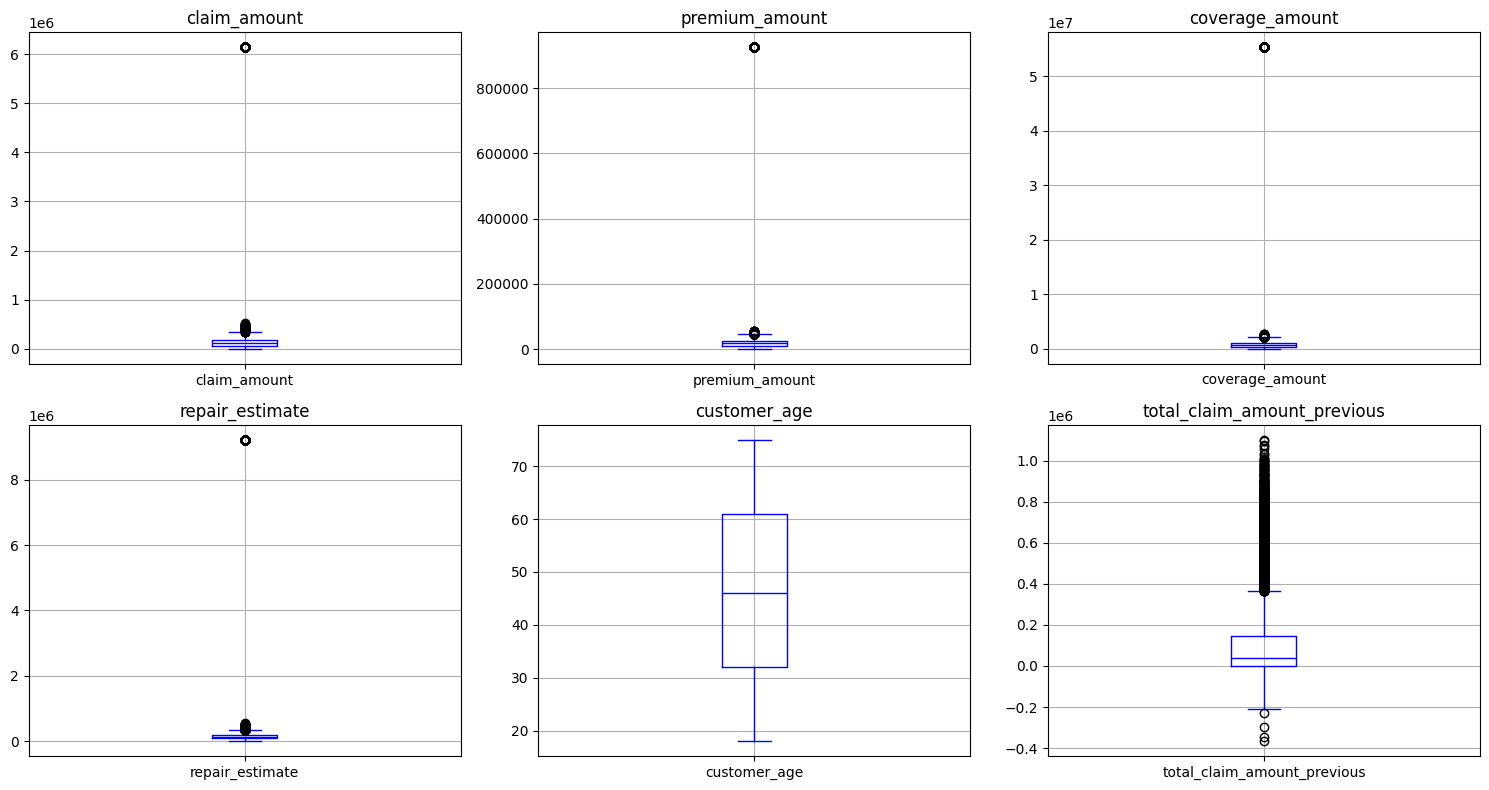

In [272]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

outlier_cols = ['claim_amount', 'premium_amount', 'coverage_amount',
                'repair_estimate', 'customer_age', 'total_claim_amount_previous']

for i, col in enumerate(outlier_cols):
    row, col_idx = i // 3, i % 3
    df_clean.boxplot(column=col, ax=axes[row, col_idx],color='blue')
    axes[row, col_idx].set_title(f'{col}')

plt.tight_layout()
plt.show()

### Outlier detection

- `claim_amount` and `repair_estimate` both have visible extreme outliers well above the upper whisker.
- `total_claim_amount_previous` shows the widest spread — past claim behavior varies hugely across customers.
- `coverage_amount` has a skewed distribution with high-value outliers, since very large policies exist in the data.
- `customer_age` looks the cleanest — no extreme outliers after our earlier invalid value treatment.
- These are not necessarily errors — extreme values are real in insurance data, but they can skew model training.

### Outlier Treatment

In [273]:
#Outlier treatment using IQR method

def cap_outliers_iqr(df, col, factor=1.5):
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    
    # Count outliers
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    # Cap
    df[col] = df[col].clip(lower=lower, upper=upper)
    
    return outliers, lower, upper

# Apply to skewed numeric columns
outlier_cols = ['claim_amount', 'premium_amount', 'coverage_amount',
                'repair_estimate', 'total_claim_amount_previous']

for col in outlier_cols:
    n_outliers, low, high = cap_outliers_iqr(df_clean, col)
    print(f"{col}: capped {n_outliers} outliers [{low:.0f}, {high:.0f}]")

claim_amount: capped 646 outliers [-109022, 351106]
premium_amount: capped 572 outliers [-9014, 45420]
coverage_amount: capped 580 outliers [-670902, 2084102]
repair_estimate: capped 809 outliers [-78293, 344483]
total_claim_amount_previous: capped 3002 outliers [-220044, 366740]


### Handled Outliers

- We used the **IQR method** — values outside 1.5x the interquartile range are capped, not deleted.
- Capping keeps all 44,491 rows while limiting the pull of extreme values on the model.
- `total_claim_amount_previous` had the most outliers (3,002) — showing high variance in past claim behavior.
- We chose capping over deletion because in fraud detection, extreme values can themselves be important fraud signals.
- Deleting outlier rows risks losing fraud cases; capping limits their statistical influence while keeping the data.

**Feature Engineering**

### Date-Based Features

In [274]:
# Policy Age 
df_clean['policy_age_days'] = (df_clean['incident_date'] - df_clean['policy_start_date']).dt.days

# Claim Submission Delay
df_clean['claim_delay_days'] = (df_clean['claim_filed_date'] - df_clean['incident_date']).dt.days

# Days to Policy Expiry 
df_clean['days_to_policy_expiry'] = (df_clean['policy_end_date'] - df_clean['incident_date']).dt.days

# Incident Month 
df_clean['incident_month'] = df_clean['incident_date'].dt.month

# Incident Weekday 
df_clean['incident_weekday'] = df_clean['incident_date'].dt.dayofweek

# Weekend Incident Flag 
df_clean['is_weekend'] = df_clean['incident_weekday'].isin([5, 6]).astype(int)

# Incident Quarter 
df_clean['incident_quarter'] = df_clean['incident_date'].dt.quarter

# Year of incident
df_clean['incident_year'] = df_clean['incident_date'].dt.year


print(df_clean[['policy_age_days', 'claim_delay_days', 'days_to_policy_expiry',
                'incident_month', 'incident_weekday', 'is_weekend', 
                'incident_quarter', 'incident_year']].head())

   policy_age_days  claim_delay_days  days_to_policy_expiry  incident_month  \
0             1172                 7                    314               5   
1              947                 6                    165               8   
3             1627               307                  -1229              12   
4              377               -86                    930               9   
5             1231                36                    724              10   

   incident_weekday  is_weekend  incident_quarter  incident_year  
0                 2           0                 2           2023  
1                 1           0                 3           2024  
3                 5           1                 4           2022  
4                 3           0                 3           2024  
5                 2           0                 4           2023  


In [275]:
df_clean['incident_date'].head()

0   2023-05-24
1   2024-08-13
3   2022-12-31
4   2024-09-05
5   2023-10-11
Name: incident_date, dtype: datetime64[ns]

In [276]:
df_clean = df_clean.drop(columns=date_cols)
df_clean.shape


(44491, 42)

### Created Date Features

- Raw date columns are not useful to ML models — we extracted meaningful numbers from them instead.
- `policy_age_days` tells us how long the policy was active before the claim.
- `claim_delay_days` is a key fraud signal — fraudsters often delay filing claims strategically to cover their tracks.
- `days_to_policy_expiry` captures whether claims are filed suspiciously close to when a policy ends.
- After feature extraction, we dropped the original date columns — the model has no use for raw date strings.

### Risk Ratio Features

In [277]:
#  Claim to Coverage Ratio 
df_clean['claim_coverage_ratio'] = df_clean['claim_amount'] / (df_clean['coverage_amount'] + 1)

# Claim to Repair Ratio
df_clean['claim_repair_ratio'] = df_clean['claim_amount'] / (df_clean['repair_estimate'] + 1)

# Premium to Coverage Ratio
df_clean['premium_coverage_ratio'] = df_clean['premium_amount'] / (df_clean['coverage_amount'] + 1)

# Deductible to Claim Ratio
df_clean['deductible_claim_ratio'] = df_clean['deductible_amount'] / (df_clean['claim_amount'] + 1)

# Previous claims average amount
df_clean['avg_previous_claim'] = df_clean['total_claim_amount_previous'] / (df_clean['previous_claims_count'] + 1)

# Current claim vs average previous claim
df_clean['claim_vs_avg_ratio'] = df_clean['claim_amount'] / (df_clean['avg_previous_claim'] + 1)


print(df_clean[['claim_coverage_ratio', 'claim_repair_ratio', 
          'premium_coverage_ratio', 'avg_previous_claim']].describe())

       claim_coverage_ratio  claim_repair_ratio  premium_coverage_ratio  \
count          44491.000000        44491.000000            44491.000000   
mean               0.476324            1.151740                0.069754   
std                0.920500            5.098800                0.125214   
min                0.002399            0.014514                0.000960   
25%                0.082425            0.765789                0.013923   
50%                0.169053            0.937835                0.025871   
75%                0.358108            1.089264                0.052944   
max                7.021990          552.652542                0.908377   

       avg_previous_claim  
count        44491.000000  
mean         26340.520933  
std          29686.108419  
min         -47097.666667  
25%              0.000000  
50%          15665.000000  
75%          52118.950000  
max         122246.666667  


### Ratios are important

- A Rs.2L claim on a Rs.50L policy is different from a Rs.2L claim on a Rs.2.1L policy.
- `claim_repair_ratio > 1` means the claimed amount exceeds the repair estimate — a strong fraud indicator.
- `premium_coverage_ratio` reveals if someone pays very little for very high coverage — a suspicious pattern.
- We added `+1` to all denominators to avoid division-by-zero errors when values are 0.
- These ratios give the model a relative view of amounts rather than just comparing raw absolute numbers.

### Risk Flag Features

In [278]:
# High claim amount flag
high_claim_threshold = df_clean['claim_amount'].quantile(0.90)
df_clean['is_high_claim'] = (df_clean['claim_amount'] > high_claim_threshold).astype(int)

# Claim > Coverage 
df_clean['claim_exceeds_coverage'] = (df_clean['claim_amount'] > df_clean['coverage_amount']).astype(int)

# No police report 
df_clean['no_police_report'] = (df_clean['police_report_available'] == 'No').astype(int)

# No witness
df_clean['no_witness'] = (df_clean['witness_available'] == 'No').astype(int)

# Late filing flag 
df_clean['late_filing'] = (df_clean['claim_delay_days'] > 30).astype(int)

# Odd hour incident
df_clean['odd_hour_incident'] = ((df_clean['incident_hour'] >= 0) & 
                            (df_clean['incident_hour'] <= 5)).astype(int)

# Frequent claimer 
df_clean['frequent_claimer'] = (df_clean['claims_last_12_months'] > 2).astype(int)

# New customer
df_clean['new_customer'] = (df_clean['customer_tenure_years'] < 1).astype(int)

# Recent policy change
df_clean['recent_policy_change'] = (df_clean['policy_changes_last_year'] > 0).astype(int)

# Poor documentation 
df_clean['poor_documentation'] = (df_clean['documentation_score'] < 5).astype(int)

# High suspicious activity 
df_clean['high_suspicion'] = (df_clean['suspicious_activity_score'] > 7).astype(int)


In [279]:
flag_cols = ['is_high_claim', 'claim_exceeds_coverage', 'no_police_report',
             'no_witness', 'late_filing', 'odd_hour_incident', 'frequent_claimer',
             'new_customer', 'recent_policy_change', 'poor_documentation',
             'high_suspicion']


for col in flag_cols:
    pct = df_clean[col].mean() * 100
    print(f"  {col}: {pct:.2f}%")

  is_high_claim: 10.00%
  claim_exceeds_coverage: 11.04%
  no_police_report: 42.67%
  no_witness: 47.58%
  late_filing: 62.35%
  odd_hour_incident: 25.42%
  frequent_claimer: 7.94%
  new_customer: 8.22%
  recent_policy_change: 39.98%
  poor_documentation: 14.87%
  high_suspicion: 8.05%


### Risk Flags 

- Over **62%** of claims were filed late (>30 days) — suspiciously high and worth close attention in modeling.
- Nearly **43%** have no police report and **48%** have no witness — large gaps in evidence documentation.
- Only ~8% are new customers or frequent claimers — rare but important fraud indicator categories.
- The `high_suspicion` flag covers just **8%** of claims — a focused red-flag group for the model to learn from.
- These binary flags encode expert domain knowledge as features — each one represents a known real-world fraud pattern.

### Composite Risk Score

In [280]:
risk_flags = ['no_police_report', 'no_witness', 'late_filing', 
              'odd_hour_incident', 'frequent_claimer', 'new_customer',
              'recent_policy_change', 'poor_documentation', 'high_suspicion',
              'claim_exceeds_coverage']

df_clean['total_risk_flags'] = df_clean[risk_flags].sum(axis=1)

print(f"Total risk flags distribution:")
print(df_clean['total_risk_flags'].value_counts().sort_index())

Total risk flags distribution:
total_risk_flags
0     1331
1     6407
2    12713
3    12918
4     7697
5     2738
6      594
7       85
8        7
9        1
Name: count, dtype: int64


### Composite Risk Score

- Most claims have **2-3 risk flags** — claims with zero flags (only 1,331) are actually the clean minority.
- Claims with **5+ flags** are rare (under 3,400 total) but are the strongest fraud candidates in the dataset.
- `total_risk_flags` gives the model a single summarized risk level — quick and human-interpretable.
- This score does not replace individual flags — both are retained so the model can use each signal independently.
- A composite score is useful not just for ML but also for building simple rule-based alert thresholds.

## Correlation Analysis

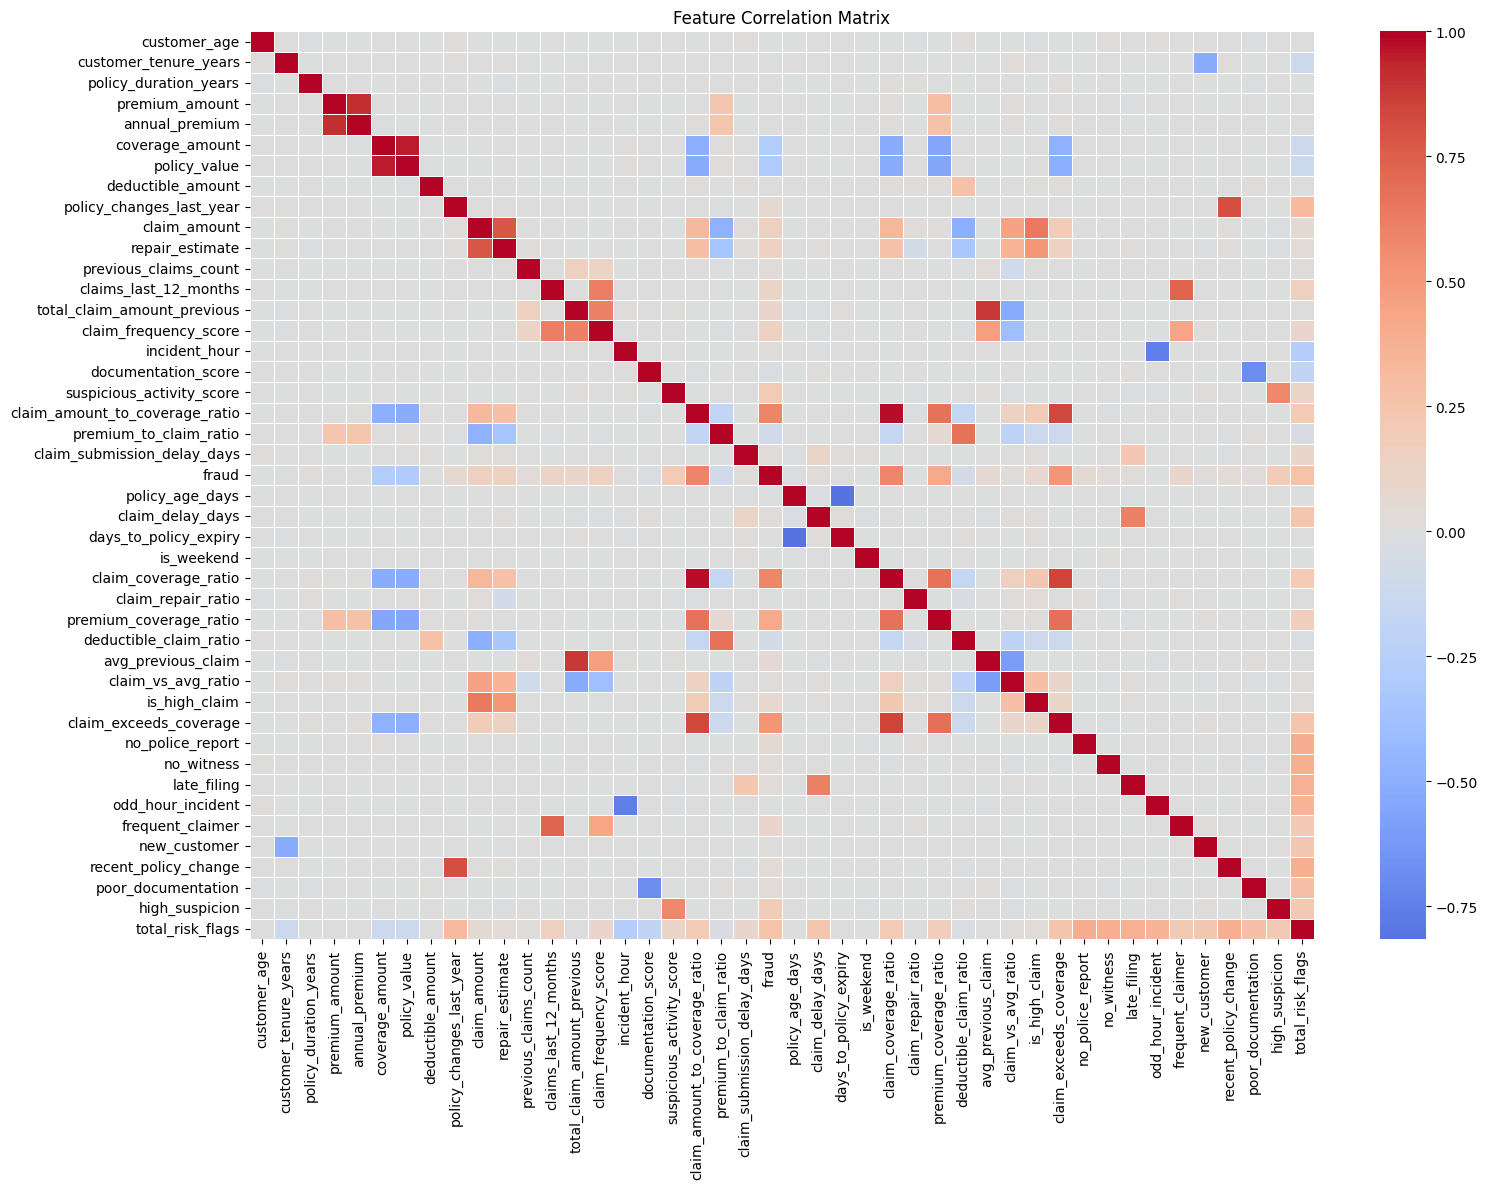

In [281]:
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            annot=False, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### Correlation Map 

- We plotted correlations across all numeric features to identify redundant pairs before modeling.
- Highly correlated features carry near-identical information — keeping both wastes model capacity.
- The heatmap helps spot clusters of related features, like claim amounts correlating with their derived ratios.
- Features with low correlation to others may still be important if they specifically correlate with fraud.
- We will use a **0.9 threshold** to flag pairs that are too similar to both keep.

### Finding Highly Correlated Feature Pairs

In [282]:
def find_high_correlation(corr_matrix, threshold=0.9):
    high_corr = []
    cols = corr_matrix.columns
    
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr.append({
                    'feature1': cols[i],
                    'feature2': cols[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    
    return pd.DataFrame(high_corr).sort_values('correlation', ascending=False)

high_corr_df = find_high_correlation(corr_matrix, threshold=0.9)
print("Highly correlated feature pairs (>0.9):")
print(high_corr_df)

Highly correlated feature pairs (>0.9):
                         feature1              feature2  correlation
2  claim_amount_to_coverage_ratio  claim_coverage_ratio     0.973098
1                 coverage_amount          policy_value     0.951959
0                  premium_amount        annual_premium     0.912266


### Dropping Redundant Correlated Features

In [283]:
drop_candidates = [
    'annual_premium',         
    'policy_value',           
    'claim_coverage_ratio'    
]


drop_candidates = [c for c in drop_candidates if c in df_clean.columns]
df_clean = df_clean.drop(columns=drop_candidates)
print(f"Dropped {len(drop_candidates)} redundant features")
df_clean.shape

Dropped 3 redundant features


(44491, 57)

### Reason for Dropping These Redundant Features

- Found **3 pairs** with correlation > 0.9 — in each pair, one column is essentially a duplicate of the other.
- `annual_premium` and `premium_amount` have 0.91 correlation — we dropped `annual_premium`, kept the more direct one.
- `policy_value` and `coverage_amount` have 0.95 correlation — `coverage_amount` is more interpretable, so `policy_value` was removed.
- `claim_coverage_ratio` and `claim_amount_to_coverage_ratio` have 0.97 correlation — kept the original and dropped the engineered one.
- After removing 3 redundant features, we have **57 clean, informative columns** — ready for model training.

## Separating Features and Target

In [285]:
y = df_clean['fraud']
X = df_clean.drop(columns=['fraud', 'claim_id'])

### Split Features and Target

- separating independent and dependent features
- `fraud` becomes our target y — 0 means a genuine claim, 1 means fraudulent.
- `claim_id` is dropped from X too because it is just a row identifier and carries zero predictive value.



## Splitting Train and Test Data

In [286]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        
    random_state=42,       
    stratify=y             
)

### Split Into Train and Test

- We kept 80% of records for training and 20% for testing.
- `stratify=y` ensures the fraud-to-genuine ratio stays the same in both train and test — critical for imbalanced data.
- `random_state=42` locks the split so the same rows always go to train and test — results stay reproducible.


## Encoding Categorical Columns

In [287]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"  {col}: {X_train[col].nunique()} unique values")
    print(f"    Values: {X_train[col].unique()}")

  gender: 2 unique values
    Values: ['Male' 'Female']
  occupation: 5 unique values
    Values: ['Student' 'Business' 'Self-Employed' 'Salaried' 'Retired']
  location_type: 3 unique values
    Values: ['Urban' 'Semi-Urban' 'Rural']
  policy_type: 6 unique values
    Values: ['Health' 'Property' 'Auto' 'Life' 'Vehicle' 'Travel']
  claim_type: 6 unique values
    Values: ['Accident' 'Theft' 'Damage' 'Medical' 'Fire' 'Loss']
  incident_severity: 4 unique values
    Values: ['Minor' 'Major' 'Moderate' 'Severe']
  incident_location: 6 unique values
    Values: ['Hospital' 'Road' 'Home' 'Other' 'Public Place' 'Workplace']
  police_report_available: 2 unique values
    Values: ['No' 'Yes']
  witness_available: 2 unique values
    Values: ['Yes' 'No']
  third_party_involved: 2 unique values
    Values: ['No' 'Yes']
  weekend_incident: 2 unique values
    Values: ['Yes' 'No']


### Encoding 

- ML models only work with numbers — text categories like `"Urban"`, `"Auto"`, `"Salaried"` mean nothing to them.
- Checking unique values first tells us which encoding method fits each column best.
- Columns with 2 values like Yes/No or Male/Female are handled with binary (0/1) encoding.
- Columns with a natural order like severity (Minor to Severe) need ordinal encoding to preserve the ranking.
- Columns with no natural order like policy type or occupation need one-hot encoding to avoid false ordering.

### Binary Encoding

In [288]:
binary_cols = ['police_report_available', 'witness_available', 
               'third_party_involved', 'weekend_incident']

binary_map = {'Yes': 1, 'No': 0}

for col in binary_cols:
    X_train[col] = X_train[col].map(binary_map)
    X_test[col] = X_test[col].map(binary_map)


gender_map = {'Male': 0, 'Female': 1}
X_train['gender'] = X_train['gender'].map(gender_map)
X_test['gender'] = X_test['gender'].map(gender_map)

print("Binary encoding done!")
print(X_train[binary_cols + ['gender']].head())

Binary encoding done!
       police_report_available  witness_available  third_party_involved  \
302                          0                  1                     0   
31608                        1                  1                     0   
29198                        1                  1                     0   
919                          1                  0                     1   
42325                        1                  0                     0   

       weekend_incident  gender  
302                   1       0  
31608                 0       0  
29198                 1       0  
919                   0       0  
42325                 0       0  


### Binary Encoding

- Yes/No columns are mapped directly to 1/0 — no extra columns created, no ordering problems.
- `gender` is mapped Male→0 and Female→1 — a simple integer the model can process cleanly.
- The exact same mapping is applied to both train and test.
- Columns encoded here: `police_report_available`, `witness_available`, `third_party_involved`, `weekend_incident`, and `gender`.

### Ordinal Encoding

In [289]:
severity_map = {
    'Minor': 1,
    'Moderate': 2,
    'Major': 3,
    'Severe': 4
}

X_train['incident_severity'] = X_train['incident_severity'].map(severity_map)
X_test['incident_severity'] = X_test['incident_severity'].map(severity_map)

print("Ordinal encoding done!")
print(X_train['incident_severity'].value_counts())

Ordinal encoding done!
incident_severity
1    14630
2    11756
3     6774
4     2432
Name: count, dtype: int64


### Ordinal Encoding for Severity

- `incident_severity` has a clear real-world order: Minor < Moderate < Major < Severe.
- We mapped it to 1, 2, 3, 4 so the model treats Severe (4) as meaningfully higher than Minor (1).
- Using one-hot encoding here would have lost this order — the model would treat all severities as equal.
- The same map is applied to both X_train and X_test to keep both datasets consistent.


### One-Hot Encoding

In [ ]:
nominal_cols = ['occupation', 'location_type', 'policy_type', 
                'claim_type', 'incident_location']

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True, dtype=int)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [297]:
print("Remaining object columns:")
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
print(obj_cols if obj_cols else "None - all encoded!")

print(f"\nX_train dtypes:\n{X_train.dtypes.value_counts()}")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Remaining object columns:
None - all encoded!

X_train dtypes:
int64      48
float64    19
int32       4
Name: count, dtype: int64

X_train shape: (35592, 71)
X_test shape: (8899, 71)


### One-Hot Encoding

- 5 nominal columns had no natural order, so each category got its own separate 0/1 column.
- `drop_first=True` removes one dummy column per group to avoid the dummy variable trap (multicollinearity).
- `X_test.reindex(columns=X_train.columns, fill_value=0)` ensures test set has the exact same columns as train — this handles unseen categories gracefully.
- After encoding, we confirmed zero text columns remain — every single feature is now a number.
- The final shapes of X_train and X_test confirm encoding was applied cleanly and consistently to both sets.

## Feature Scaling

In [296]:
binary_like_cols = []
continuous_cols = []

for col in X_train.columns:
    unique_vals = X_train[col].nunique()
    if unique_vals <= 2:
        binary_like_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"Continuous columns (will scale): {len(continuous_cols)}")


Continuous columns (will scale): 33


In [299]:
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Scaling done!")
print("\nTrain statistics :")
print(X_train[continuous_cols[:3]].describe().round(2))

print("\nTest statistics :")
print(X_test[continuous_cols[:3]].describe().round(2))

Scaling done!

Train statistics :
       customer_age  customer_tenure_years  policy_duration_years
count      35592.00               35592.00               35592.00
mean           0.00                   0.00                  -0.00
std            1.00                   1.00                   1.00
min           -1.69                  -1.81                  -1.75
25%           -0.86                  -0.70                  -0.77
50%           -0.02                  -0.02                  -0.04
75%            0.87                   0.66                   0.69
max            1.71                   4.27                   4.54

Test statistics :
       customer_age  customer_tenure_years  policy_duration_years
count       8899.00                8899.00                8899.00
mean           0.01                   0.01                   0.01
std            1.00                   0.99                   1.00
min           -1.69                  -1.81                  -1.75
25%           -0.86    

### Scaled the Features

- Features like `claim_amount` (in thousands) and `claim_delay_days` (in days) live on very different scales.
- Without scaling, algorithms like Logistic Regression treat large-scale columns as more important — even if they are not.
- `StandardScaler` centers each continuous column at mean=0 and scales it to standard deviation=1.
- We used `fit_transform` on train data and `transform` only on test — fitting on test would leak its statistics into the scaler.
- Binary and flag columns (0/1) were deliberately excluded — scaling those would distort their meaning.

## Saving Processed Data

In [301]:
os.makedirs(r'C:\NG\insurance_fraud_detection\data\processed', exist_ok=True)
os.makedirs(r'C:\NG\insurance_fraud_detection\models', exist_ok=True)

X_train.to_csv(r'C:\NG\insurance_fraud_detection\data\processed\X_train.csv', index=False)
X_test.to_csv(r'C:\NG\insurance_fraud_detection\data\processed\X_test.csv', index=False)
pd.DataFrame(y_train, columns=['fraud']).to_csv(r'C:\NG\insurance_fraud_detection\data\processed\y_train.csv', index=False)
pd.DataFrame(y_test, columns=['fraud']).to_csv(r'C:\NG\insurance_fraud_detection\data\processed\y_test.csv', index=False)

joblib.dump(scaler, r'C:\NG\insurance_fraud_detection\models\scaler.pkl')
joblib.dump(continuous_cols, r'C:\NG\insurance_fraud_detection\models\scaling_cols.pkl')
joblib.dump(binary_like_cols, r'C:\NG\insurance_fraud_detection\models\binary_cols.pkl')

feature_names = X_train.columns.tolist()
joblib.dump(feature_names, r'C:\NG\insurance_fraud_detection\models\feature_names.pkl')

encoding_maps = {
    'binary_map': binary_map,
    'gender_map': gender_map,
    'severity_map': severity_map,
    'nominal_cols': nominal_cols  
}
joblib.dump(encoding_maps, r'C:\NG\insurance_fraud_detection\models\encoding_maps.pkl')

print(" All artifacts saved!")
print("\nFiles created:")
print("  data/processed/X_train.csv, X_test.csv, y_train.csv, y_test.csv")
print("  models/scaler.pkl, scaling_cols.pkl, binary_cols.pkl")
print("  models/feature_names.pkl, encoding_maps.pkl")

print(f"\nFinal training shape: {X_train.shape}")
print(f"Final test shape: {X_test.shape}")
print(f"Total features: {len(feature_names)}")

 All artifacts saved!

Files created:
  data/processed/X_train.csv, X_test.csv, y_train.csv, y_test.csv
  models/scaler.pkl, scaling_cols.pkl, binary_cols.pkl
  models/feature_names.pkl, encoding_maps.pkl

Final training shape: (35592, 71)
Final test shape: (8899, 71)
Total features: 71


### Saved the processed data

- We saved 4 CSV files — `X_train`, `X_test`, `y_train`, `y_test` — one for each split of features and labels.
- The scaler, encoding maps, and feature names are saved as `.pkl` files — these must be reused identically in production to avoid inconsistencies.
- Saving these artifacts means we can reload and train models anytime without redoing the full preprocessing pipeline.
- All outputs go into the `processed/` folder — clean separation from raw data keeps the project organized.
- These files are the final ready-to-train inputs — no further cleaning, encoding, or scaling needed after this point.